In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
dataset='/content/drive/MyDrive/ieee-fraud-detection/datasets'
data=os.listdir(dataset)
print(data)

['sample_submission.csv', 'test_identity.csv', 'test_transaction.csv', 'train_identity.csv', 'train_transaction.csv', 'y_train.npy', 'y_test.npy', 'X_train_scaled.npy', 'X_test_scaled.npy', 'feature_names.json']


In [ ]:
train_trans=pd.read_csv(dataset+'/train_transaction.csv')
train_id=pd.read_csv(dataset+'/train_identity.csv')

In [ ]:
print(train_trans.shape)
print(train_id.shape)

(590540, 394)
(144233, 41)


In [ ]:
print(train_trans.columns)
print(train_id.columns)

Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5',
       ...
       'V330', 'V331', 'V332', 'V333', 'V334', 'V335', 'V336', 'V337', 'V338',
       'V339'],
      dtype='object', length=394)
Index(['TransactionID', 'id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06',
       'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'id_12', 'id_13', 'id_14',
       'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22',
       'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30',
       'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38',
       'DeviceType', 'DeviceInfo'],
      dtype='object')


In [ ]:
df=pd.merge(train_trans,train_id,on='TransactionID',how='left')

In [ ]:
import gc
del train_trans, train_id
gc.collect()

123

In [ ]:
print(df.shape)

(590540, 434)


In [ ]:
data=df.copy

In [ ]:
pd.set_option('display.max_rows',None)

In [ ]:
def reduce_mem(df):
    for c in df.columns:
        t = df[c].dtype
        if t == object: continue
        if str(t).startswith("int"): df[c] = pd.to_numeric(df[c], downcast="integer")
        else: df[c] = df[c].astype(np.float32)
    return df

df = reduce_mem(df)
fraud_rate = df["isFraud"].mean()
print(f'{fraud_rate:.3%}')

3.499%


In [ ]:
fraud_count=df['isFraud'].value_counts()
print(fraud_count)

isFraud
0    569877
1     20663
Name: count, dtype: int64


In [ ]:
fraud_pct=df['isFraud'].value_counts(normalize=True)*100
print(fraud_pct)

isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


In [ ]:
print(df.head(5))

   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        2987000        0          86400            68.5         W  13926   
1        2987001        0          86401            29.0         W   2755   
2        2987002        0          86469            59.0         W   4663   
3        2987003        0          86499            50.0         W  18132   
4        2987004        0          86506            50.0         H   4497   

   card2  card3       card4  card5  ...                id_31  id_32  \
0    NaN  150.0    discover  142.0  ...                  NaN    NaN   
1  404.0  150.0  mastercard  102.0  ...                  NaN    NaN   
2  490.0  150.0        visa  166.0  ...                  NaN    NaN   
3  567.0  150.0  mastercard  117.0  ...                  NaN    NaN   
4  514.0  150.0  mastercard  102.0  ...  samsung browser 6.2   32.0   

       id_33           id_34  id_35 id_36 id_37  id_38  DeviceType  \
0        NaN             NaN    NaN   Na

In [ ]:
missing=(df.isna().sum()/len(df) *100).sort_values(ascending=False)
print(missing.head(15))

id_24    99.196159
id_25    99.130965
id_07    99.127070
id_08    99.127070
id_21    99.126393
id_26    99.125715
id_27    99.124699
id_23    99.124699
id_22    99.124699
dist2    93.628374
D7       93.409930
id_18    92.360721
D13      89.509263
D14      89.469469
D12      89.041047
dtype: float64


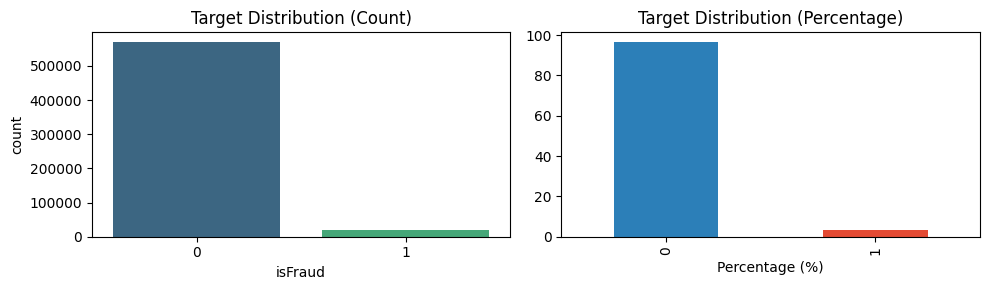

In [ ]:
fig, axes=plt.subplots(1,2,figsize=(10,3))
sns.countplot(x="isFraud", data=df,ax=axes[0],palette='viridis')
axes[0].set_title('Target Distribution (Count)')
axes[0].set_xlabel("isFraud")
(df['isFraud'].value_counts(normalize=True)*100).plot(kind='bar',ax=axes[1],color=["#2c7fb8", "#e34a33"])
axes[1].set_title('Target Distribution (Percentage)')
axes[1].set_xlabel("Percentage (%)")
plt.tight_layout()
plt.show()

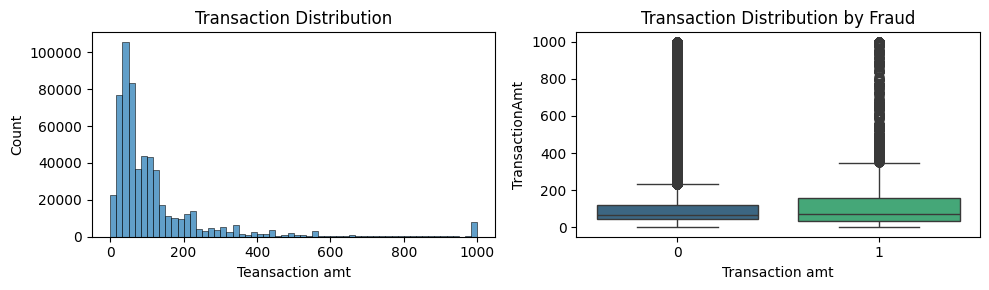

In [ ]:
fig, axes=plt.subplots(1,2,figsize=(10,3))
sns.histplot(df['TransactionAmt'].clip(upper=1000),bins=60,ax=axes[0],color="#2c7fb8")
axes[0].set_title('Transaction Distribution')
axes[0].set_xlabel('Teansaction amt')
sns.boxplot(x='isFraud',y=df['TransactionAmt'].clip(upper=1000),data=df,ax=axes[1],palette='viridis')
axes[1].set_title('Transaction Distribution by Fraud')
axes[1].set_xlabel('Transaction amt')
plt.tight_layout()
plt.show()

In [ ]:
num_cols=df.select_dtypes(include=[np.number]).columns
top_corr_fraud=df[num_cols].corr()['isFraud'].abs().sort_values(ascending=False).index[1:16]
print(top_corr_fraud)

Index(['V257', 'V246', 'V244', 'V242', 'V201', 'V200', 'V189', 'V188', 'V258',
       'V45', 'V158', 'V156', 'V149', 'V228', 'V44'],
      dtype='object')


In [ ]:
gc.collect()

5285

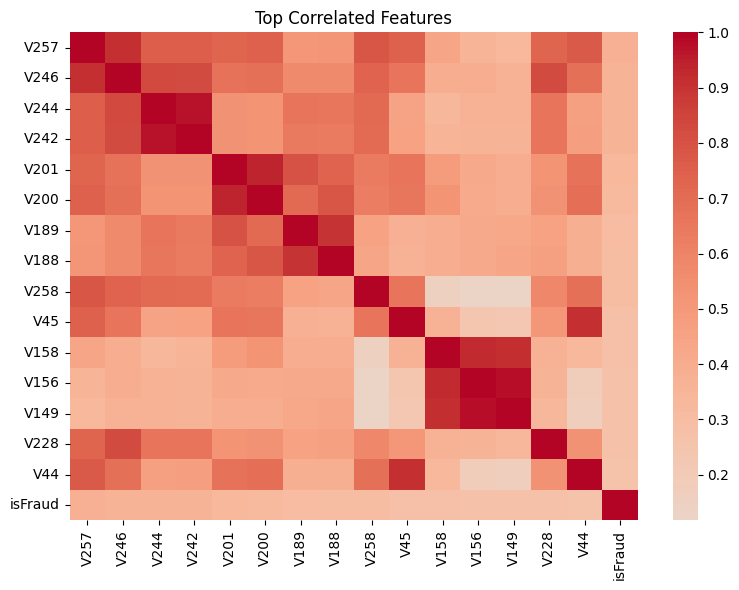

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df[list(top_corr_fraud)+['isFraud']].corr(),annot=False,cmap='coolwarm',center=0)
plt.title('Top Correlated Features')
plt.tight_layout()
plt.show()

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns

cat_df = pd.DataFrame({
    'dtype': df[cat_cols].dtypes,
    'nunique': df[cat_cols].nunique(),
    'missing_pct': (df[cat_cols].isna().sum() * 100 / len(df))
}).sort_values('nunique', ascending=False)

print(cat_df)

                dtype  nunique  missing_pct
DeviceInfo     object     1786    79.905510
id_33          object      260    87.589494
id_31          object      130    76.245132
id_30          object       75    86.865411
R_emaildomain  object       60    76.751617
P_emaildomain  object       59    15.994852
ProductCD      object        5     0.000000
card6          object        4     0.266028
card4          object        4     0.267044
id_34          object        4    86.824771
id_15          object        3    76.126088
M4             object        3    47.658753
id_23          object        3    99.124699
M2             object        2    45.907136
M1             object        2    45.907136
id_12          object        2    75.576083
M9             object        2    58.633115
M8             object        2    58.633115
M7             object        2    58.635317
M6             object        2    28.678836
M5             object        2    59.349409
M3             object        2  

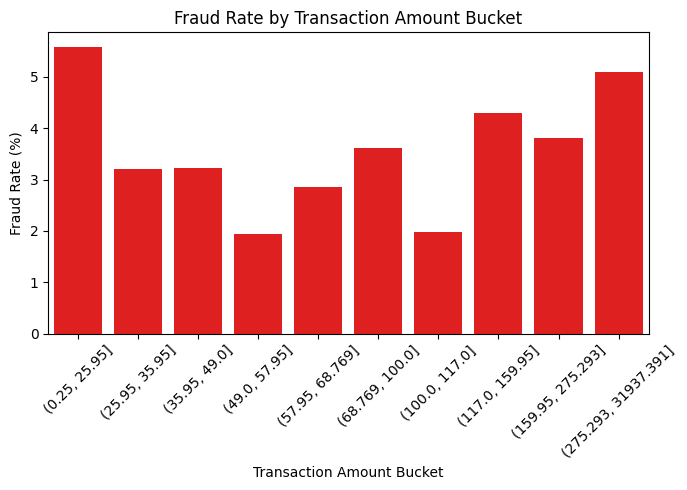

In [ ]:
df['_amt_bucket']=pd.qcut(df['TransactionAmt'],q=10,duplicates='drop')
fraud_by_bucket_df=df.groupby('_amt_bucket')['isFraud'].mean().reset_index()
fraud_by_bucket_df['isFraud'] = fraud_by_bucket_df['isFraud'] * 100
plt.figure(figsize=(7,5))
sns.barplot(x='_amt_bucket',y='isFraud',data=fraud_by_bucket_df,color='red')
plt.title('Fraud Rate by Transaction Amount Bucket')
plt.xlabel('Transaction Amount Bucket')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
fraud_by_bucket_df

,_amt_bucket,isFraud
0,"(0.25, 25.95]",5.588883
1,"(25.95, 35.95]",3.205191
2,"(35.95, 49.0]",3.225014
3,"(49.0, 57.95]",1.943099
4,"(57.95, 68.769]",2.851295
5,"(68.769, 100.0]",3.616955
6,"(100.0, 117.0]",1.974223
7,"(117.0, 159.95]",4.302602
8,"(159.95, 275.293]",3.803734
9,"(275.293, 31937.391]",5.086956


In [ ]:
# Data Cleaning
missing_cols=df.isnull().mean()
missing_cols=missing_cols[missing_cols>0.90].index.tolist()
df.drop(columns=missing_cols,inplace=True)

before=len(df)
df.drop_duplicates(inplace=True)

In [ ]:
zero_variance_cols = df.columns[df.nunique(dropna=False) <= 1].tolist()
print(zero_variance_cols)

[]


In [ ]:
num_cols=df.select_dtypes(include=[np.number]).columns
cat_cols=df.select_dtypes(include=['object']).columns
print(num_cols.size,'\n',cat_cols.size)

393 
 29


In [ ]:
for c in num_cols:
  if df[c].isnull().any():
    df[c]=df[c].fillna(df[c].median())

for c in cat_cols:
  if df[c].isnull().any():
    mode=df[c].mode(dropna=True)
    df[c]=df[c].fillna(mode.iloc[0] if len(mode) else 'missing')

In [ ]:
gc.collect()

0

In [ ]:
df['TransactionDT'].head(5)

,TransactionDT
0,86400
1,86401
2,86469
3,86499
4,86506


In [ ]:
second_in_day=24*60*60
df['txn_hour']=(df['TransactionDT']*3600)%24
df['txn_day']=(df['TransactionDT']/second_in_day).astype(int)
df['txn_weekday']=df['txn_day']%7
df['is_weekend']=df['txn_weekday'].isin([5,6]).astype(int)
df['is_night']=df['txn_hour'].between(0,6).astype(int)

In [ ]:
df['amt_log']=np.log1p(df['TransactionAmt'])
df['amt_bin']=pd.qcut(df['TransactionAmt'],q=10,duplicates='drop',labels=False)
df['amt_percent']=df['TransactionAmt'].rank(pct=True)
df['amt_zscore']=(df['TransactionAmt']-df['TransactionAmt'].mean())/df['TransactionAmt'].std()

In [ ]:
df['is_same_mail']=(df['P_emaildomain']==df['R_emaildomain']).astype(int)

In [ ]:
email_freq=df['P_emaildomain'].value_counts(normalize=True)
df['email_rarity']=df['P_emaildomain'].map(email_freq).fillna(0)
df['email_is_rare']=(df['email_rarity']<0.01).astype(int)

In [ ]:
from sklearn.preprocessing import LabelEncoder
cat_cols=[c for c in df.select_dtypes(include=['object']).columns if c is not 'isFraud']

encoders={}
for c in cat_cols:
  le=LabelEncoder()
  df[c]=le.fit_transform(df[c].astype(str))
  encoders[c]=le

print(cat_cols)

['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


In [ ]:
from sklearn.model_selection import train_test_split
drop_cols=['TransactionID','isFraud']
X=df.drop(columns=drop_cols)
y=df['isFraud']

feature_cols=X.columns.to_list()

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

print(feature_cols)
print(f"Train Shape: {X_train.shape}, Test Shape: {X_test.shape}")
print(f"Train Fraud rate: {y_train.mean()*100:.3%}")
print(f"Test Fraud rate: {y_test.mean()*100:.3%}")

['TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V82', 'V83', 'V84', 'V85', 'V86', 'V87', 'V8

In [ ]:
X_train.drop(columns=['_amt_bucket'], inplace=True, errors='ignore')
X_test.drop(columns=['_amt_bucket'], inplace=True, errors='ignore')

In [ ]:
X_train_np = X_train.astype(np.float32).values
X_test_np = X_test.astype(np.float32).values

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_np=scaler.fit_transform(X_train_np)
X_test_np=scaler.transform(X_test_np)

In [ ]:
np.save('/content/drive/MyDrive/ieee-fraud-detection/X_train_scaled.npy',X_train_np)
np.save('/content/drive/MyDrive/ieee-fraud-detection/X_test_scaled.npy',X_test_np)
np.save('/content/drive/MyDrive/ieee-fraud-detection/y_train.npy',y_train.values)
np.save('/content/drive/MyDrive/ieee-fraud-detection/y_test.npy',y_test.values)

In [ ]:
import json
with open('/content/drive/MyDrive/ieee-fraud-detection/feature_names.json','w') as f:
  json.dump(X_train.columns.to_list(),f)

In [ ]:
gc.collect()

3898

In [ ]:
imputations={}
for c in num_cols:
  imputations[c]=df[c].median()

for c in cat_cols:
  mode=df[c].mode(dropna=True)
  imputations[c]=str(encoders[c].inverse_transform([int(mode)])[0])

In [ ]:
_, amt_bin_edges = pd.qcut(df['TransactionAmt'], q=10, duplicates='drop', retbins=True)

amt_mean = float(df['TransactionAmt'].mean())
amt_std = float(df['TransactionAmt'].std())
amt_sorted_train = np.sort(df['TransactionAmt'].values)

In [ ]:
import joblib,json

In [ ]:
saving_dir='/content/drive/MyDrive/ieee-fraud-detection/'

joblib.dump(encoders,saving_dir+'label_encoders.pkl')
joblib.dump(scaler,saving_dir+'scaler.pkl')

json.dump(imputations,open(saving_dir+'imputation_values.json','w'))
json.dump(email_freq.to_dict(),open(saving_dir+'email_frq_lookup.json','w'))
json.dump(missing_cols,open(saving_dir+'dropped_columns.json','w'))

np.save(saving_dir+'amt_bin_edges.npy',amt_bin_edges)
np.save(saving_dir+'amt_sorted_train.npy',amt_sorted_train)

json.dump({'mean':amt_mean,'std': amt_std},open(saving_dir+'amt_zscores','w'))

print("Everything saved")

Everything saved


In [ ]:
new_amount = 0.27
bucket = pd.cut([new_amount], bins=amt_bin_edges, labels=False, include_lowest=True)[0]

In [ ]:
bucket

np.int64(0)

In [ ]:
import json


json.dump({"mean": 135.02716064453125, "std": 239.16268920898438}, open('/content/drive/MyDrive/ieee-fraud-detection/amt_zscore_stats.json', 'w'))

print(amt_mean, amt_std)

135.02716064453125 239.16268920898438
